In [ ]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sys
import os

In [ ]:


# Get the current working directory (where the notebook is located)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)

from data_creator import load_2D
df = load_2D().dropna() # load data from files

In [5]:


X = df[['Area', 'Circumference', 'CoA', 'MU', "Span", "MCS"]].dropna()

scale = StandardScaler()
scaled_X = scale.fit_transform(X)
y = (df["AD"]).dropna()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size = 0.25, random_state = 42)


In [15]:
models = {
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
    "Ridge": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
}

Lasso:
  RMSE: 7.1810
  R^2:  0.3541
  Coefficients: {'Area': np.float64(0.14461817270349137), 'Circumference': np.float64(0.7766648705024779), 'CoA': np.float64(-0.0), 'MU': np.float64(-0.5459243784895738), 'Span': np.float64(-3.7749878187694703), 'MCS': np.float64(4.245565552537479)}
----------------------------------------
Ridge:
  RMSE: 7.0913
  R^2:  0.3701
  Coefficients: {'Area': np.float64(2.0966774077488153), 'Circumference': np.float64(0.6197936734077447), 'CoA': np.float64(-1.6456627175655254), 'MU': np.float64(-0.7721893015424619), 'Span': np.float64(-4.581626239626344), 'MCS': np.float64(4.641913613175676)}
----------------------------------------
ElasticNet:
  RMSE: 7.2132
  R^2:  0.3483
  Coefficients: {'Area': np.float64(0.37871033094310375), 'Circumference': np.float64(0.32716068828009703), 'CoA': np.float64(-0.07515550980501015), 'MU': np.float64(-0.5992301027198133), 'Span': np.float64(-3.4106835398520134), 'MCS': np.float64(4.05239304081155)}
-----------------------

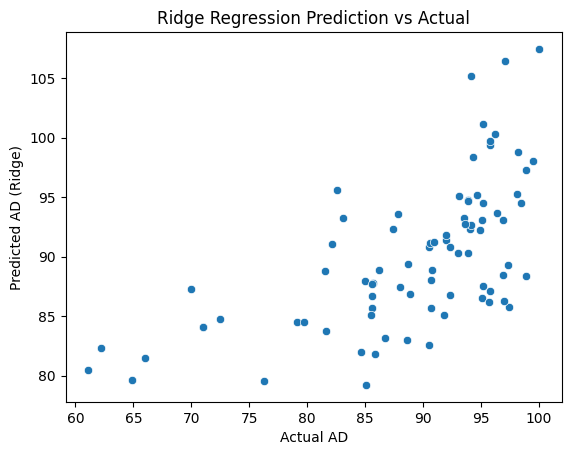

In [ ]:


results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "RMSE": mean_squared_error(y_test, y_pred)**0.5,
        "R2": r2_score(y_test, y_pred),
        "Coefficients": model.coef_
    }
    print(f"{name}:")
    print(f"  RMSE: {results[name]['RMSE']:.4f}")
    print(f"  R^2:  {results[name]['R2']:.4f}")
    print(f"  Coefficients: {dict(zip(X.columns, model.coef_))}")
    print("-" * 40)

